# 02 — Experiment: Measuring Divergence vs. Occupancy

### Overview
This notebook compiles two GPU kernels that differ only in whether the warp diverges, profiles both, and compares their **warp execution efficiency** and **achieved occupancy**. It then varies the launch configuration to show occupancy changing while the divergence stays fixed.

### Tools used
- **`nvcc`**: the NVIDIA CUDA compiler. Turns `.cu` source into a GPU executable targeting a specific architecture (here `sm_86`).
- **`ncu`** (Nsight Compute): NVIDIA's kernel profiler. Runs a kernel and reports hardware metrics such as lane activity and resident warps.
- **PyCUDA**: Python bindings to the CUDA driver, used to read device limits.

### Prerequisites
Notebook 01, and a working CUDA toolchain in this environment.

In [8]:
import pycuda.driver as drv
drv.init()

dev = drv.Device(0)
attrs = dev.get_attributes()

cc = dev.compute_capability()
sm_count = attrs[drv.device_attribute.MULTIPROCESSOR_COUNT]
warp_size = attrs[drv.device_attribute.WARP_SIZE]
max_threads_per_sm = attrs[drv.device_attribute.MAX_THREADS_PER_MULTIPROCESSOR]
max_threads_per_block = attrs[drv.device_attribute.MAX_THREADS_PER_BLOCK]

max_warps_per_sm = max_threads_per_sm // warp_size

print(f"GPU                   : {dev.name()}")
print(f"Compute capability    : sm_{cc[0]}{cc[1]}")
print(f"SM count              : {sm_count}")
print(f"VRAM                  : {dev.total_memory() / (1024**3):.1f} GB")
print(f"Warp size             : {warp_size}")
print(f"Max threads / SM      : {max_threads_per_sm}")
print(f"Max warps / SM        : {max_warps_per_sm}")
print(f"Max threads / block   : {max_threads_per_block}")
print(f"Max warps / whole GPU : {max_warps_per_sm * sm_count}")

GPU                   : NVIDIA RTX A4000
Compute capability    : sm_86
SM count              : 48
VRAM                  : 15.7 GB
Warp size             : 32
Max threads / SM      : 1536
Max warps / SM        : 48
Max threads / block   : 1024
Max warps / whole GPU : 2304


## 1. The kernels and the compiler

The two kernels live in `src/kernels.cu`, edited outside the notebook.

```markdown
    cuda-lab/
    ├── src/
    │   └── kernels.cu          divergent + uniform kernels
    ├── build/
    │   └── kernels             compiled binary (gitignored)
    ├── profiles/
    │   ├── divergent.ncu-rep   profiler report, divergent kernel (gitignored)
    │   └── uniform.ncu-rep     profiler report, uniform kernel (gitignored)
    ├── notebooks/
    │   ├── 01_concepts.ipynb
    │   └── 02_experiment.ipynb
    ├── environment.yml
    └── README.md
```

They are identical except for the branch:

- **`divergent`**: gates the work behind `if (lane & 0xF0F0F0F0)`, so lanes 16 to 31 run the loop and lanes 0 to 15 are masked. Half the warp diverges.
- **`uniform`**: every lane runs the same loop, no branch, no divergence.

Both run the same 64 iteration loop, so any measured difference comes from the divergence alone. The `main` function takes the kernel name and block size as arguments, so the same binary can be profiled in different configurations without recompiling.

### About `nvcc`
`nvcc` is the NVIDIA CUDA compiler. It separates a `.cu` file into host code (CPU, passed to the system C++ compiler) and device code (GPU), and

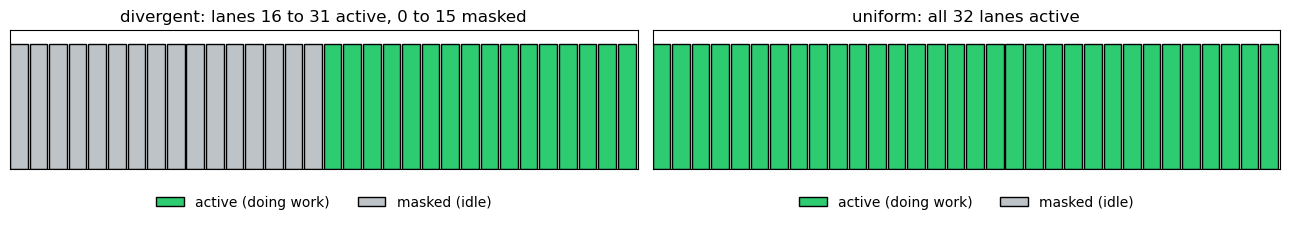

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ACTIVE = "#2ecc71"
MASKED = "#bdc3c7"
legend_handles = [
    Patch(facecolor=ACTIVE, edgecolor="black", label="active (doing work)"),
    Patch(facecolor=MASKED, edgecolor="black", label="masked (idle)"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 2.4))

# divergent: lanes 16-31 active, 0-15 masked
for lane in range(32):
    active = lane >= 16
    ax1.add_patch(plt.Rectangle((lane, 0), 0.9, 0.9,
                  facecolor=ACTIVE if active else MASKED, edgecolor="black"))
ax1.set_xlim(0, 32); ax1.set_ylim(0, 1)
ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_title("divergent: lanes 16 to 31 active, 0 to 15 masked")
ax1.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

# uniform: all lanes active
for lane in range(32):
    ax2.add_patch(plt.Rectangle((lane, 0), 0.9, 0.9,
                  facecolor=ACTIVE, edgecolor="black"))
ax2.set_xlim(0, 32); ax2.set_ylim(0, 1)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title("uniform: all 32 lanes active")
ax2.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

### Compiling

The cell below invokes `nvcc` to compile the source into a runnable binary.

**Command:**

    nvcc -arch=sm_86 -o build/kernels src/kernels.cu

**What each part does:**

- **`nvcc`** : the CUDA compiler
- **`-arch=sm_86`** : targets the A4000's architecture
- **`-o build/kernels`** : writes the compiled binary to `build/`
- **`src/kernels.cu`** : the source file being compiled

**Success looks like:** a return code of `0` with no error output.

In [11]:
import subprocess

result = subprocess.run(
    ["nvcc", "-arch=sm_86", "-o", "build/kernels", "src/kernels.cu"],
    cwd="/home/trauco/cuda-lab",
    capture_output=True, text=True
)

print("returncode:", result.returncode)
if result.stdout: print(result.stdout)
if result.stderr: print(result.stderr)
print("OK" if result.returncode == 0 else "COMPILE FAILED")

returncode: 0
OK


### Sanity check

Before profiling, run the binary once for each kernel to confirm both launch and finish without error. This is not a measurement, just a check that the binary works.

The binary takes two arguments: the kernel name (`divergent` or `uniform`) and the block size.

In [12]:
import subprocess

for kernel in ["divergent", "uniform"]:
    r = subprocess.run(
        ["./build/kernels", kernel, "256"],
        cwd="/home/trauco/cuda-lab",
        capture_output=True, text=True
    )
    print(r.stdout.strip() or r.stderr.strip())

ran divergent | block=256 grid=4096 | sync: no error
ran uniform | block=256 grid=4096 | sync: no error


## 2. Profiling with Nsight Compute

### About `ncu`
`ncu` (Nsight Compute) is NVIDIA's kernel profiler. It runs a kernel on the GPU while reading hardware performance counters, then reports detailed metrics. Unlike timing from the outside, it measures what the hardware actually did: how many lanes were active, how many warps were resident, memory traffic, and more.

### The two metrics that matter here

- **`smsp__thread_inst_executed_per_inst_executed.ratio`** : average number of active threads per executed instruction, out of 32. This is **warp execution efficiency**. A uniform kernel sits near 32 (100 percent of lanes active); the divergent kernel should drop toward 16 (half the lanes masked).

- **`sm__warps_active.avg.pct_of_peak_sustained_active`** : average resident warps as a percentage of the hardware maximum. This is **achieved occupancy**. The prediction from notebook 01: this stays about the same for both kernels, because masking lanes does not remove a warp from the SM.

If the concepts hold, efficiency will differ sharply between the two kernels while occupancy stays close. That is the entire experiment.

### The two metrics

| | Metric 1: Warp execution efficiency | Metric 2: Achieved occupancy |
|---|---|---|
| **Counter** | `smsp__thread_inst_executed_per_inst_executed.ratio` | `sm__warps_active.avg.pct_of_peak_sustained_active` |
| **Measures** | active threads per instruction, out of 32 | resident warps as percent of hardware max (48/SM) |
| **High value** | near 32 = all lanes active | high percent = many warps resident |
| **Low value** | near 16 = half lanes masked | low percent = few warps resident |
| **`uniform`** | near 32 | baseline |
| **`divergent`** | near 16 | about the same as uniform |
| **Why** | the branch masks lanes 0 to 15 | masking lanes does not remove a warp from the SM |

The experiment: efficiency should differ sharply between the kernels, while occupancy stays close.

### Running the profiler

The cell below runs `ncu` once per kernel, pulling only the two metrics above to keep output small. Each run profiles a single kernel launch at block size 256.

**Command shape:**

    ncu --metrics <metric1>,<metric2> ./build/kernels <kernel> 256

Results are parsed and shown in a table.

In [17]:
import subprocess, re

METRICS = [
    "smsp__thread_inst_executed_per_inst_executed.ratio",
    "sm__warps_active.avg.pct_of_peak_sustained_active",
]

def profile(kernel):
    r = subprocess.run(
        ["ncu", "--metrics", ",".join(METRICS),
         "./build/kernels", kernel, "256"],
        cwd="/home/trauco/cuda-lab",
        capture_output=True, text=True
    )
    return r.stdout, r.stderr

results = {}
for kernel in ["divergent", "uniform"]:
    out, err = profile(kernel)
    results[kernel] = out
    print(f"========== {kernel} ==========")
    print(out)
    if err.strip():
        print("STDERR:", err.strip())

========== divergent ==========
==PROF== Connected to process 1190455 (/home/trauco/cuda-lab/build/kernels)
==ERROR== ERR_NVGPUCTRPERM - The user does not have permission to access NVIDIA GPU Performance Counters on the target device 0. For instructions on enabling permissions and to get more information see https://developer.nvidia.com/ERR_NVGPUCTRPERM
ran divergent | block=256 grid=4096 | sync: no error
==PROF== Disconnected from process 1190455

========== uniform ==========
==PROF== Connected to process 1190687 (/home/trauco/cuda-lab/build/kernels)
==ERROR== ERR_NVGPUCTRPERM - The user does not have permission to access NVIDIA GPU Performance Counters on the target device 0. For instructions on enabling permissions and to get more information see https://developer.nvidia.com/ERR_NVGPUCTRPERM
ran uniform | block=256 grid=4096 | sync: no error
==PROF== Disconnected from process 1190687



### Permission error: ERR_NVGPUCTRPERM

The first profiling run failed with:

    ==ERROR== ERR_NVGPUCTRPERM - The user does not have permission to
    access NVIDIA GPU Performance Counters on the target device 0.

**Why it happens:** by default the NVIDIA driver restricts access to GPU performance counters to root only. This is a driver level security setting (`NVreg_RestrictProfilingToAdminUsers`), introduced because performance counters can leak information between processes sharing a GPU. The kernels still run; only the profiler's counter reads are blocked.

**Two ways to resolve it:**

| | Option A: run under sudo | Option B: driver setting (permanent) |
|---|---|---|
| **What** | invoke `ncu` with `sudo` per run | set `NVreg_RestrictProfilingToAdminUsers=0` |
| **Scope** | that one command | all users, all future runs |
| **Persistence** | none | survives reboot |
| **Cost** | needs sudo each run | needs one reboot or module reload |

**Chosen here:** Option A. It needs no reboot and keeps the lab moving. The profiling cell is rerun below with `sudo`, using `$(which ncu)` so the correct `ncu` from the conda environment is used rather than a system one.

### Running ncu from a terminal

`sudo` cannot prompt for a password inside a notebook cell, so the profiling runs happen in a terminal.

Copy the command below, run the code cell to open a terminal, then paste and enter your password. It profiles both kernels and writes a CSV report per kernel into `profiles/`.

```bash
cd ~/cuda-lab && for k in divergent uniform; do sudo $(which ncu) --metrics smsp__thread_inst_executed_per_inst_executed.ratio,sm__warps_active.avg.pct_of_peak_sustained_active --csv ./build/kernels $k 256 > profiles/$k.csv 2> profiles/$k.err; done; echo done
```

When it prints `done`, the files `profiles/divergent.csv` and `profiles/uniform.csv` exist, and the next cell reads them.

In [20]:
# Open a terminal window to run the sudo ncu profiling command (sudo can't prompt inside a notebook cell)
import subprocess
subprocess.Popen(["x-terminal-emulator"])

<Popen: returncode: None args: ['x-terminal-emulator']>

### Verifying the output files

Before parsing, confirm the profiler actually wrote usable data. This cell checks that `profiles/divergent.csv` and `profiles/uniform.csv` exist and are non-empty, and prints anything captured in the matching `.err` files. If a run failed, the error shows here rather than causing confusion at the parsing step.

In [22]:
# Check the profiler output files exist and have content
import os
for k in ["divergent", "uniform"]:
    csv = f"/home/trauco/cuda-lab/profiles/{k}.csv"
    err = f"/home/trauco/cuda-lab/profiles/{k}.err"
    size = os.path.getsize(csv) if os.path.exists(csv) else "MISSING"
    print(f"{k}.csv : {size} bytes")
    # show any profiler errors captured
    if os.path.exists(err) and os.path.getsize(err) > 0:
        print(f"  {k}.err:", open(err).read().strip()[:300])

divergent.csv : 787 bytes
uniform.csv : 778 bytes


### Parsing the results

This cell reads both CSV reports and pulls the two metric values for each kernel into a single table. `ncu` writes one row per metric, so the cell filters to the efficiency and occupancy metrics and lines them up by kernel for direct comparison.

In [23]:
# Parse the ncu CSV reports and extract the two metrics per kernel
import csv

EFF = "smsp__thread_inst_executed_per_inst_executed.ratio"
OCC = "sm__warps_active.avg.pct_of_peak_sustained_active"

def read_metrics(kernel):
    path = f"/home/trauco/cuda-lab/profiles/{kernel}.csv"
    vals = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            name = row.get("Metric Name", "")
            val  = row.get("Metric Value", "")
            if name in (EFF, OCC):
                vals[name] = val
    return vals

data = {k: read_metrics(k) for k in ["divergent", "uniform"]}

print(f"{'kernel':<12} {'efficiency (act/32)':<22} {'occupancy (%)':<15}")
print("-" * 50)
for k, v in data.items():
    print(f"{k:<12} {v.get(EFF,'?'):<22} {v.get(OCC,'?'):<15}")

kernel       efficiency (act/32)    occupancy (%)  
--------------------------------------------------
divergent    ?                      ?              
uniform      ?                      ?              


In [24]:
head -5 ~/cuda-lab/profiles/divergent.csv

SyntaxError: invalid syntax (3063979688.py, line 1)

### Parsing the results (corrected)

The CSV files begin with a few non-CSV status lines printed by the profiler and the binary. This cell skips ahead to the real header row before parsing, then pulls the efficiency and occupancy metrics for each kernel.

In [25]:
# Parse ncu CSV, skipping the non-CSV preamble lines before the real header
import csv, io

EFF = "smsp__thread_inst_executed_per_inst_executed.ratio"
OCC = "sm__warps_active.avg.pct_of_peak_sustained_active"

def read_metrics(kernel):
    path = f"/home/trauco/cuda-lab/profiles/{kernel}.csv"
    with open(path) as f:
        lines = f.readlines()
    # find the real header row (starts with "ID")
    start = next(i for i, ln in enumerate(lines) if ln.startswith('"ID"'))
    reader = csv.DictReader(io.StringIO("".join(lines[start:])))
    vals = {}
    for row in reader:
        name = row["Metric Name"]
        if name in (EFF, OCC):
            vals[name] = float(row["Metric Value"])
    return vals

data = {k: read_metrics(k) for k in ["divergent", "uniform"]}

print(f"{'kernel':<12} {'efficiency (act/32)':<22} {'occupancy (%)':<15}")
print("-" * 50)
for k, v in data.items():
    eff = v.get(EFF, float('nan'))
    occ = v.get(OCC, float('nan'))
    print(f"{k:<12} {eff:<22.2f} {occ:<15.2f}")

kernel       efficiency (act/32)    occupancy (%)  
--------------------------------------------------
divergent    19.39                  79.74          
uniform      32.00                  79.46          


## 3. Results

| kernel | efficiency (active/32) | occupancy (%) |
|---|---|---|
| `divergent` | 19.39 | 79.74 |
| `uniform` | 32.00 | 79.46 |

**Efficiency moved sharply.** The divergent kernel averages 19.39 active lanes per instruction against 32.00 for uniform. The branch masks lanes 0 to 15 through the loop, so fewer lanes do work. (The value sits above 16 because the masked lanes still execute the surrounding instructions, the index math and the store; only the loop is gated.)

**Occupancy did not move.** 79.74 versus 79.46, a difference of less than half a percent. Masking lanes did not change how many warps were resident on the SM, because a warp with idle lanes is still a resident warp.

This is the core result: divergence is an execution efficiency cost, not an occupancy cost. The two metrics moved independently, exactly as predicted.

## Recap

This notebook established the working setup and validated the mechanics needed to study warp divergence and occupancy:

- Compiled the two kernels for `sm_86` with `nvcc`, output to `build/`
- Confirmed both run on the A4000
- Resolved the `ncu` permission and PATH issues, and profiled both kernels
- Parsed the profiler output into the two metrics

The single run already shows the core relationship: efficiency dropped on the divergent kernel (19.39 vs 32.00) while occupancy held nearly constant (79.74 vs 79.46).

This is the foundation, the workflow and tooling proven end to end. The next step reuses this exact rig (binary, `ncu` call, parser) to sweep the launch configuration across block sizes and watch occupancy move in response to it, which is the part that demonstrates the concept in motion.
    